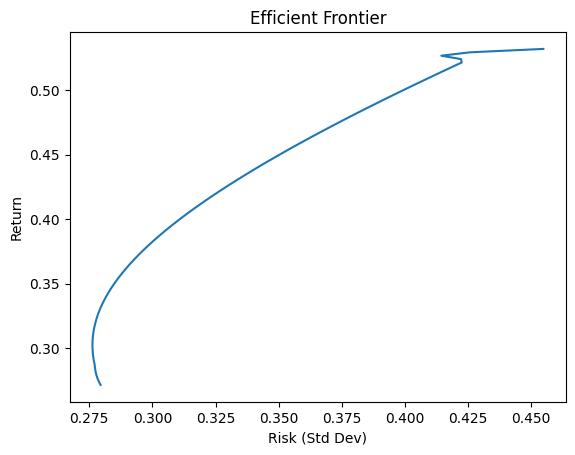

Best Portfolio:
Return: 0.5268747287537375
Risk: 0.4144084868225398
Sharpe: 1.1145397438530837
Weights: [0.69322025 0.         0.30677975]


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd


# Phase1 = Data Collection
#Raw Data from yfiannce
def get_raw_data(tickers,period):
  data = {}
  for ticker in tickers:
    df = yf.Ticker(ticker).history(period = period)
    if df.empty :
      raise ValueError("No Value found",ticker)
    data[ticker]=df["Close"]

  return data


#Join data from yfinance
def data_combine(dict):
  price_df = pd.DataFrame(dict)
  return price_df



#Clean Align the df
def clean_df(price_df):
  price_df = price_df.sort_index()
  clean_df = price_df.dropna()
  if clean_df.empty:
    raise ValueError("No Common data Between the assets")
  return clean_df


#Combining all three helper methods to master methods
def data_df(tickers,period):
  raw_info = get_raw_data(tickers,period)
  combined_data = data_combine(raw_info)
  data_df = clean_df(combined_data)
  return data_df







#Phase 2 = Calculate Expected Value and CoVariance
#Calculating daily percentage change
def calc_returns(price_df):
  returns = price_df.pct_change()
  returns = returns.dropna()
  return returns



#Calculating mean returns
def calc_mu(returns_df):
  mu = returns_df.mean()
  return mu



#Calculating covariance
def calc_sigma(returns_df):
  sigma = returns_df.cov()
  return sigma


#Calculating risk model as a helper model:
def calc_mu_sigma(returns_df):
  mu = calc_mu(returns_df)
  sigma = calc_sigma(returns_df)
  return mu,sigma






#Phase 3 = Optimizer
#Optimizing using scipy
from scipy.optimize import minimize

def portfolio_var(weights,sigma):
  return weights.T @ sigma @ weights

#constraints
def weight_constraint(weights):
  return sum(weights)-1

def return_constraint(weights, mu, target_return):
  return weights @ mu - target_return

#All the helpers of phase 3 joined together
def optimize_portfolio(mu, sigma, target_return):
    n_assets = len(mu)

    initial_weights = np.array([1/n_assets] * n_assets)

    bounds = [(0, 1) for _ in range(n_assets)]

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w: w @ mu - target_return}
    ]

    result = minimize(
        fun=portfolio_var,
        x0=initial_weights,
        args=(sigma,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    return result.x


#Phase 4 = Efficient Curve
def plot_efficient_frontier(mu,sigma):
  import matplotlib.pyplot as plt
  min_return = mu.min()
  max_return = mu.max()

  target_returns = np.linspace(min_return,max_return,100)

  result = []
  risks = []
  returns = []
  weights_list = []
  sharpe_ratio = []
  for target in target_returns:
    try:
      weights = optimize_portfolio(mu,sigma,target)

      portfolio_return = weights @ mu
      portfolio_risk = np.sqrt(weights.T @ sigma @ weights)
      portfolio_return = portfolio_return*252
      portfolio_risk = portfolio_risk * 15.8745078664
      portfolio_sharpe = (portfolio_return - 0.065)/portfolio_risk
      result.append((portfolio_risk,portfolio_return))
      risks.append(portfolio_risk)
      returns.append(portfolio_return)
      weights_list.append(weights)
      sharpe_ratio.append(portfolio_sharpe)

    except:
      continue

  plt.plot(risks, returns)
  plt.xlabel("Risk (Std Dev)")
  plt.ylabel("Return")
  plt.title("Efficient Frontier")
  plt.show()

  max_index = np.argmax(sharpe_ratio)
  best_weights = weights_list[max_index]
  best_return = returns[max_index]
  best_risk = risks[max_index]
  best_sharpe = sharpe_ratio[max_index]

  print("Best Portfolio:")
  print("Return:", best_return)
  print("Risk:", best_risk)
  print("Sharpe:", best_sharpe)
  print("Weights:", best_weights)


def portfolio_optimizer(portfolio,period,expected_returns):
  prices = data_df(portfolio,period)
  #print(prices)
  returns_df = calc_returns(prices)
  exp_value,co_var = calc_mu_sigma(returns_df)
  #print(returns_df)
  #print(exp_value)
  #print(co_var)
  weights = optimize_portfolio(exp_value,co_var,expected_returns)
  #print(weights)
  plot  = plot_efficient_frontier(exp_value,co_var)
  return plot



portfolio = ["NVDA","AAPL",'TSLA']
portfolio_optimizer(portfolio,'max',0.18)



